# Modular exponentiations

**Problem:** We want to compute the value
$$y = b^e \mod m$$
given $b$, $e$ and $m$.

First, let's import the libraries. 

Note that we are using the Matplotlib library just to plot a comparison between the different algorithms. You can install it by running the command:

```pip3 install matplotlib```

In [8]:
import time
import matplotlib.pyplot as plt

## The obvious solution

Let's start with the obvious solution. 

We simply multiply $b$ by itself $e$ times (and then reduce modulo $m$).

The result is accumulated in the variable $y$.

In [9]:
def mod_exp_basic(b, e, m):
    y = 1
    for i in range(e):
        y = (y * b) % m # Reduce mod m to prevent size increase.
    return y

Note that we are performing $O(e)$ multiplication operations.

Can we do better?

## An improved solution

We can implement a more efficient solution if we take into account the binary representation of the exponent $e$.

Indeed, we can write the exponent $e = \sum_{i=1}^{k}{e_i \times 2^i}$ with $e_i \in \{0, 1\}$ for all $i \in \{1,\dots,k\}$.

Then we can rewrite $y = b^e \mod m$ as follows

$$y = b^e = b^{\sum_{i=1}^{k}{e_i \times 2^i}} = \prod_{i=1}^{k}{b^{e_i \times 2^i}} \mod m$$

Note that:

1) The terms $b^{e_i \times 2^i}$ where $e_i = 0$ do not really contribute to the product (as they equal 1).
2) The terms $b^{e_i \times 2^i}$ where $e_i = 1$ become equal to $b^{2^i}$.

Thus, we can devise the following function that loops over the bits of the exponent.

In [21]:
def mod_exp_sm(b, e, m):
    # We accumulate the result in the y variable.
    y = 1
    # Then we loop over the bits of the exponent.
    while e:
        # If the exponent is 1, we multiply y by the current value of b.
        if e & 1: 
            y = (y * b) % m
        # We always square b, i.e., compute the next b^(2^i).
        b = (b * b) % m 
        e >>= 1 # Shift to the next bit
    return y

## Comparison

Let's compare the running time of our two functions. We want to compute $y = 3^{2120} \mod 31$.

In [11]:
start_time = time.time_ns()
result = mod_exp_sm(3, 2120, 31)
end_time = time.time_ns()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} ns")
print(f"Result: {result}")

Elapsed time: 112000 ns
Result: 5


In [12]:
start_time = time.time_ns()
result = mod_exp_basic(3, 2120, 31)
end_time = time.time_ns()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} ns")
print(f"Result: {result}")

Elapsed time: 416000 ns
Result: 5


## Another (visual) comparison

We can compare the running time of the functions by evaluating them on different exponents.

We also include in this comparison the built-in Python ```pow()``` function that computes a power in modular arithmetic.

For the evaluation, we compute $y = 2^e \mod 71$ for all values of $e \in \{2^i : i \in \mathbb{Z} \wedge 0 \leq i \leq 24\}$.

In [53]:
exponents = [(2**i) for i in range(0, 24)] 
exp_lengths = []
result_basic = []
result_sm = []
result_def = []

# We fix a base and a modulus
b = 2
m = 71

for e in exponents:
  exp_lengths.append(e.bit_length())

  start_time = time.time_ns()
  result = mod_exp_basic(b, e, m)
  end_time = time.time_ns()
  result_basic.append(end_time - start_time)

  start_time = time.time_ns()
  result = mod_exp_sm(b, e, m)
  end_time = time.time_ns()
  result_sm.append(end_time - start_time)

  start_time = time.time_ns()
  result = pow(b, e, m)
  end_time = time.time_ns()
  result_def.append(end_time - start_time)

We plot the result using Matplotlib. 

On the x-axis we report the bit length of the evaluated exponents. 

Notice the log scale on the y-axis, which describes the running time of the functions expressed in nanoseconds.

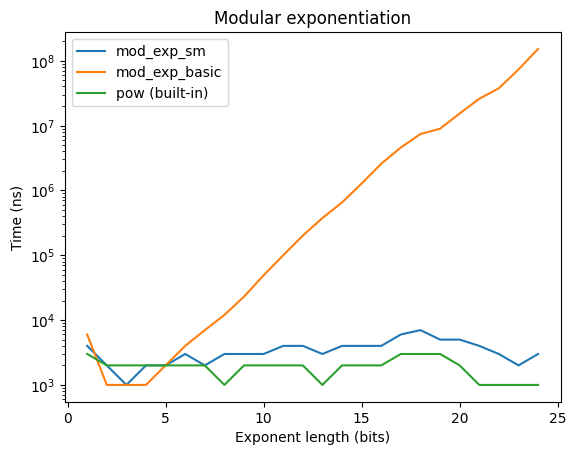

In [56]:
plt.title("Modular exponentiation")
plt.plot(exp_lengths, result_sm, label="mod_exp_sm")
plt.plot(exp_lengths, result_basic, label="mod_exp_basic")
plt.plot(exp_lengths, result_def, label="pow (built-in)")
plt.yscale("log")
plt.xlabel("Exponent length (bits)")
plt.ylabel("Time (ns)")
plt.legend()
plt.show()